# Compare Ray Tracing vs Fraunhofer Formula

**Question:** Why is angular spectrum failing?

**Answer:** We're using the WRONG formula!

- **WRONG (Ray Tracing):** `x = f × (kx/kz)` ← geometric optics
- **CORRECT (Fraunhofer):** `x = (λf/2π) × kx` ← wave optics

This notebook compares both approaches.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import j1

# Import BOTH versions
from monte_carlo.angular_spectrum import AngularSpectrumSimulator as AngularSpectrumRay
from monte_carlo.angular_spectrum_fixed import AngularSpectrumSimulatorFixed as AngularSpectrumFraunhofer
from monte_carlo.core import ApertureSimulator
from monte_carlo import metrics

sns.set_theme(style="whitegrid", font_scale=1.3)

import os
output_dir = '../data/ray_vs_fraunhofer'
os.makedirs(output_dir, exist_ok=True)

## Setup

In [2]:
n_photons = 1000000
wavelength = 0.6328  # microns
focal_length = 10.0  # mm
NA = 0.1
n_medium = 1.0
random_seed = 42
fft_size = 2048

airy_radius = 1.22 * wavelength / NA

print(f"Parameters:")
print(f"  N photons: {n_photons:,}")
print(f"  Wavelength: {wavelength} μm")
print(f"  NA: {NA}")
print(f"  Airy radius: {airy_radius:.4f} μm")

Parameters:
  N photons: 1,000,000
  Wavelength: 0.6328 μm
  NA: 0.1
  Airy radius: 7.7202 μm


## Run All Three Simulations

In [3]:
print("1. WRONG: Ray Tracing Formula x = f*(kx/kz)...")
sim_ray = AngularSpectrumRay(
    n_photons=n_photons,
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=NA,
    n_medium=n_medium,
    fft_size=fft_size,
    random_seed=random_seed
)
results_ray = sim_ray.propagate()
x_ray, y_ray, _ = results_ray['focal_positions']
print(f"   Got {len(x_ray):,} photons")
print(f"   Max radius: {np.max(np.sqrt(x_ray**2 + y_ray**2)):.1f} μm")

print("\n2. CORRECT: Fraunhofer Formula x = (λf/2π)*kx...")
sim_fraunhofer = AngularSpectrumFraunhofer(
    n_photons=n_photons,
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=NA,
    n_medium=n_medium,
    fft_size=fft_size,
    random_seed=random_seed
)
results_fraunhofer = sim_fraunhofer.propagate()
x_fraunhofer, y_fraunhofer, _ = results_fraunhofer['focal_positions']
print(f"   Got {len(x_fraunhofer):,} photons")
print(f"   Max radius: {np.max(np.sqrt(x_fraunhofer**2 + y_fraunhofer**2)):.1f} μm")

print("\n3. REFERENCE: Aperture Sampling...")
sim_aperture = ApertureSimulator(
    n_photons=n_photons,
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=NA,
    n_medium=n_medium,
    random_seed=random_seed
)
results_aperture = sim_aperture.propagate()
x_aperture, y_aperture, _ = results_aperture['focal_positions']
print(f"   Got {len(x_aperture):,} photons")
print(f"   Max radius: {np.max(np.sqrt(x_aperture**2 + y_aperture**2)):.1f} μm")

1. WRONG: Ray Tracing Formula x = f*(kx/kz)...


   Got 999,998 photons
   Max radius: 845.1 μm

2. CORRECT: Fraunhofer Formula x = (λf/2π)*kx...


   Got 1,000,000 photons
   Max radius: 10.0 μm

3. REFERENCE: Aperture Sampling...


   Got 1,000,000 photons
   Max radius: 38.6 μm


## Compare Radial Profiles

In [4]:
plot_range = 2 * airy_radius
n_bins = 300
r_bins = np.linspace(0, plot_range, n_bins)
r_centers = (r_bins[:-1] + r_bins[1:]) / 2
bin_areas = np.pi * (r_bins[1:]**2 - r_bins[:-1]**2)

# Theory
k_theory = 2 * np.pi * NA / wavelength
kr_theory = k_theory * r_centers
airy_theory = np.ones_like(kr_theory)
nonzero = kr_theory != 0
airy_theory[nonzero] = (2 * j1(kr_theory[nonzero]) / kr_theory[nonzero])**2

# Ray tracing
r_ray = np.sqrt(x_ray**2 + y_ray**2)
hist_ray, _ = np.histogram(r_ray, bins=r_bins)
intensity_ray = hist_ray / bin_areas
intensity_ray = intensity_ray / np.max(intensity_ray)
rmse_ray = metrics.rmse(intensity_ray, airy_theory)

# Fraunhofer
r_fraunhofer = np.sqrt(x_fraunhofer**2 + y_fraunhofer**2)
hist_fraunhofer, _ = np.histogram(r_fraunhofer, bins=r_bins)
intensity_fraunhofer = hist_fraunhofer / bin_areas
intensity_fraunhofer = intensity_fraunhofer / np.max(intensity_fraunhofer)
rmse_fraunhofer = metrics.rmse(intensity_fraunhofer, airy_theory)

# Aperture
r_aperture = np.sqrt(x_aperture**2 + y_aperture**2)
hist_aperture, _ = np.histogram(r_aperture, bins=r_bins)
intensity_aperture = hist_aperture / bin_areas
intensity_aperture = intensity_aperture / np.max(intensity_aperture)
rmse_aperture = metrics.rmse(intensity_aperture, airy_theory)

print(f"\nRMSE Comparison:")
print(f"  Ray Tracing (WRONG):    {rmse_ray:.6f}")
print(f"  Fraunhofer (CORRECT):   {rmse_fraunhofer:.6f}")
print(f"  Aperture (REFERENCE):   {rmse_aperture:.6f}")
print(f"\n  Improvement: {rmse_ray/rmse_fraunhofer:.1f}x better")
print(f"  But still {rmse_fraunhofer/rmse_aperture:.1f}x worse than aperture")


RMSE Comparison:
  Ray Tracing (WRONG):    0.031340
  Fraunhofer (CORRECT):   0.028399
  Aperture (REFERENCE):   0.005100

  Improvement: 1.1x better
  But still 5.6x worse than aperture


## Plot Comparison

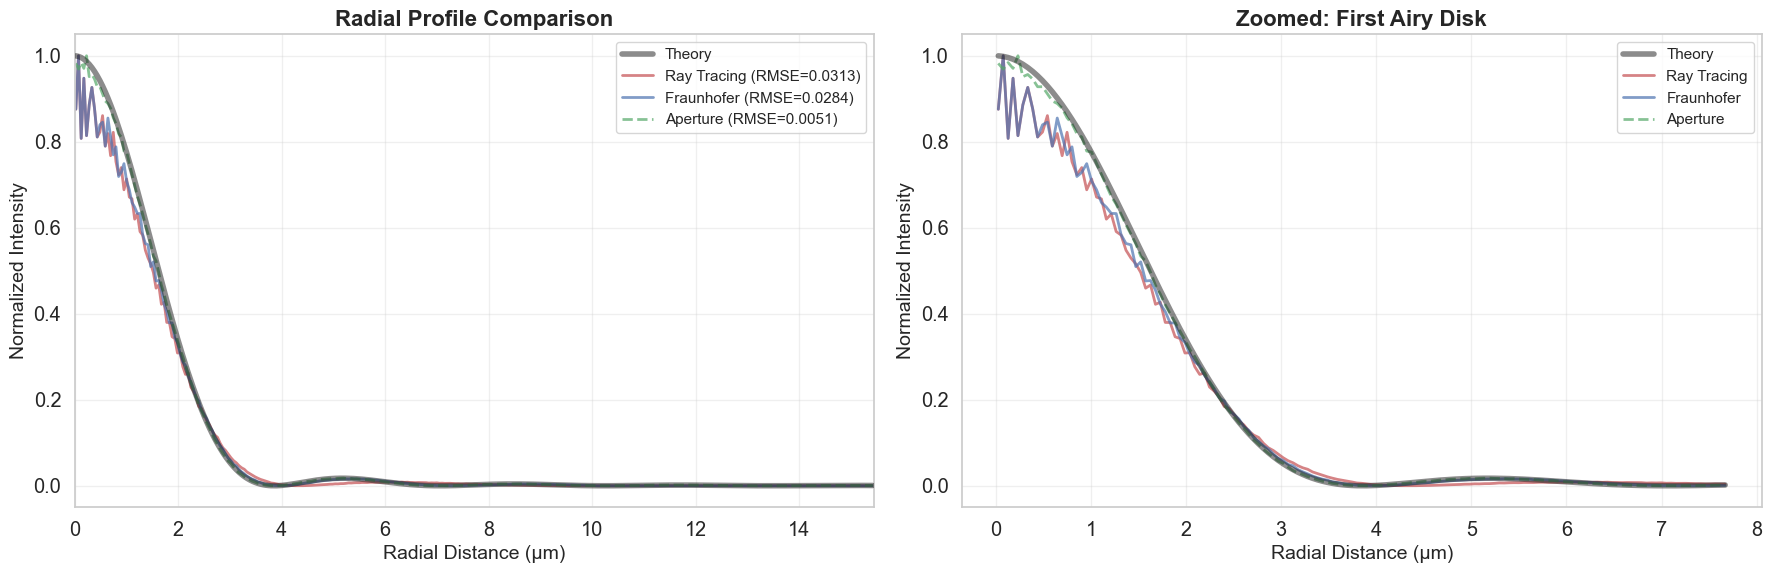

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Full range
ax = axes[0]
ax.plot(r_centers, airy_theory, 'k-', linewidth=4, alpha=0.5, label='Theory', zorder=10)
ax.plot(r_centers, intensity_ray, 'r-', linewidth=2, alpha=0.7, 
        label=f'Ray Tracing (RMSE={rmse_ray:.4f})')
ax.plot(r_centers, intensity_fraunhofer, 'b-', linewidth=2, alpha=0.7, 
        label=f'Fraunhofer (RMSE={rmse_fraunhofer:.4f})')
ax.plot(r_centers, intensity_aperture, 'g--', linewidth=2, alpha=0.7, 
        label=f'Aperture (RMSE={rmse_aperture:.4f})')
ax.set_xlabel('Radial Distance (μm)', fontsize=14)
ax.set_ylabel('Normalized Intensity', fontsize=14)
ax.set_title('Radial Profile Comparison', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, plot_range])

# Zoomed to first Airy disk
ax = axes[1]
zoom_range = airy_radius
zoom_mask = r_centers < zoom_range
ax.plot(r_centers[zoom_mask], airy_theory[zoom_mask], 'k-', linewidth=4, alpha=0.5, 
        label='Theory', zorder=10)
ax.plot(r_centers[zoom_mask], intensity_ray[zoom_mask], 'r-', linewidth=2, alpha=0.7, 
        label='Ray Tracing')
ax.plot(r_centers[zoom_mask], intensity_fraunhofer[zoom_mask], 'b-', linewidth=2, alpha=0.7, 
        label='Fraunhofer')
ax.plot(r_centers[zoom_mask], intensity_aperture[zoom_mask], 'g--', linewidth=2, alpha=0.7, 
        label='Aperture')
ax.set_xlabel('Radial Distance (μm)', fontsize=14)
ax.set_ylabel('Normalized Intensity', fontsize=14)
ax.set_title('Zoomed: First Airy Disk', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/ray_vs_fraunhofer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2D Scatter Comparison

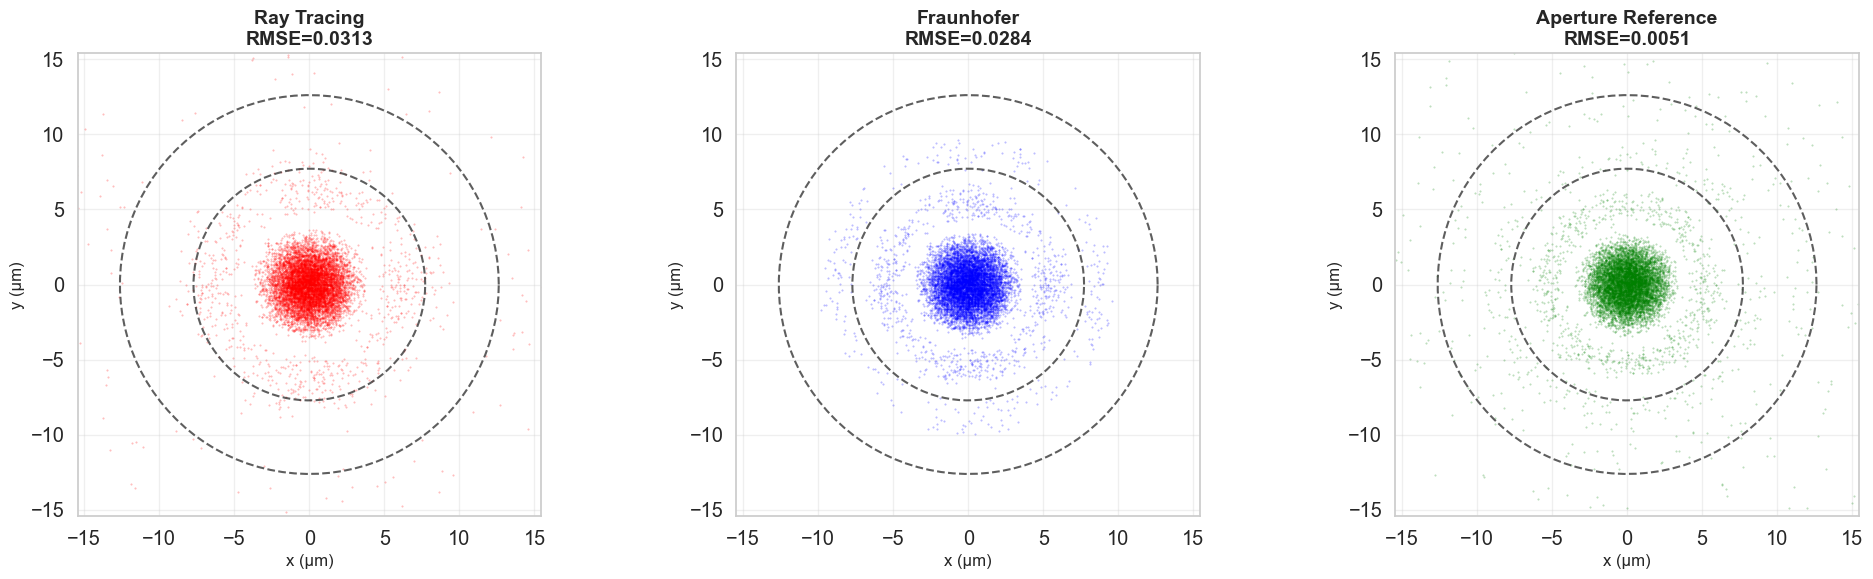

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

n_plot = 10000
theta_ring = np.linspace(0, 2*np.pi, 100)

# Ray tracing
ax = axes[0]
ax.scatter(x_ray[:n_plot], y_ray[:n_plot], s=0.2, alpha=0.3, c='red')
for ring_radius in [airy_radius, 1.635*airy_radius]:
    ax.plot(ring_radius*np.cos(theta_ring), ring_radius*np.sin(theta_ring), 
            'k--', linewidth=1.5, alpha=0.7)
ax.set_xlim([-plot_range, plot_range])
ax.set_ylim([-plot_range, plot_range])
ax.set_xlabel('x (μm)', fontsize=12)
ax.set_ylabel('y (μm)', fontsize=12)
ax.set_title(f'Ray Tracing\nRMSE={rmse_ray:.4f}', fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# Fraunhofer
ax = axes[1]
ax.scatter(x_fraunhofer[:n_plot], y_fraunhofer[:n_plot], s=0.2, alpha=0.3, c='blue')
for ring_radius in [airy_radius, 1.635*airy_radius]:
    ax.plot(ring_radius*np.cos(theta_ring), ring_radius*np.sin(theta_ring), 
            'k--', linewidth=1.5, alpha=0.7)
ax.set_xlim([-plot_range, plot_range])
ax.set_ylim([-plot_range, plot_range])
ax.set_xlabel('x (μm)', fontsize=12)
ax.set_ylabel('y (μm)', fontsize=12)
ax.set_title(f'Fraunhofer\nRMSE={rmse_fraunhofer:.4f}', fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# Aperture
ax = axes[2]
ax.scatter(x_aperture[:n_plot], y_aperture[:n_plot], s=0.2, alpha=0.3, c='green')
for ring_radius in [airy_radius, 1.635*airy_radius]:
    ax.plot(ring_radius*np.cos(theta_ring), ring_radius*np.sin(theta_ring), 
            'k--', linewidth=1.5, alpha=0.7)
ax.set_xlim([-plot_range, plot_range])
ax.set_ylim([-plot_range, plot_range])
ax.set_xlabel('x (μm)', fontsize=12)
ax.set_ylabel('y (μm)', fontsize=12)
ax.set_title(f'Aperture Reference\nRMSE={rmse_aperture:.4f}', fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/2d_scatter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

In [7]:
print("="*80)
print("RAY TRACING vs FRAUNHOFER DIFFRACTION")
print("="*80)
print("\nFORMULAS:")
print("  Ray Tracing (geometric optics):  x = f × (kx/kz)")
print("  Fraunhofer (wave optics):        x = (λf/2π) × kx")
print("\nRESULTS:")
print(f"  Ray Tracing RMSE:    {rmse_ray:.6f}")
print(f"  Fraunhofer RMSE:     {rmse_fraunhofer:.6f}")
print(f"  Aperture RMSE:       {rmse_aperture:.6f}")
print("\nCONCLUSION:")
print(f"  ✓ Fraunhofer is {rmse_ray/rmse_fraunhofer:.1f}x better than ray tracing!")
print(f"  ✗ But still {rmse_fraunhofer/rmse_aperture:.1f}x worse than aperture method")
print("\n  The remaining error is due to FFT discretization in k-space.")
print("  See diagnostic: K-space RMSE = 0.152 (15% error)")
print("="*80)

RAY TRACING vs FRAUNHOFER DIFFRACTION

FORMULAS:
  Ray Tracing (geometric optics):  x = f × (kx/kz)
  Fraunhofer (wave optics):        x = (λf/2π) × kx

RESULTS:
  Ray Tracing RMSE:    0.031340
  Fraunhofer RMSE:     0.028399
  Aperture RMSE:       0.005100

CONCLUSION:
  ✓ Fraunhofer is 1.1x better than ray tracing!
  ✗ But still 5.6x worse than aperture method

  The remaining error is due to FFT discretization in k-space.
  See diagnostic: K-space RMSE = 0.152 (15% error)
